In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean


In [37]:
file_name = "Model_prediction_scores.pkl"  # Name der Datei
file_paths_list = []  # Liste zum Speichern der Pfade

for root, _, files in os.walk("."):  # Durchsuche das aktuelle Verzeichnis und Unterordner
    if file_name in files:
        file_paths_list.append(os.path.join(root, file_name)) 

In [38]:
file_paths_list

['.\\Klassifizierung\\Model_prediction_scores.pkl',
 '.\\Prediction_Classes_Data\\Text\\Model_prediction_scores.pkl',
 '.\\Prediction_Classes_Data\\Theses\\Model_prediction_scores.pkl',
 '.\\Prediction_Data\\Text\\Model_prediction_scores.pkl',
 '.\\Prediction_Data\\Theses\\Model_prediction_scores.pkl',
 '.\\SpaCy_Prediction_Data\\Text\\Model_prediction_scores.pkl',
 '.\\SpaCy_Prediction_Data\\These\\Model_prediction_scores.pkl']

In [39]:
pd.read_pickle('.\\Klassifizierung\\Model_prediction_scores.pkl')

,model,lable_text_column,party_text_column,Manifesto_sorted,accuracy,precision,recall,f1
0,manifestoberta-xlm-roberta-56policy-topics-con...,These,These,class prefitted,0.394737,0.598413,0.395238,0.374074


In [40]:
Model_prediction_scores = pd.concat([pd.read_pickle(file_path) for file_path in file_paths_list], ignore_index=True)


In [41]:
Model_prediction_scores.columns


Index(['model', 'lable_text_column', 'party_text_column', 'Manifesto_sorted',
       'accuracy', 'precision', 'recall', 'f1'],
      dtype='object')

In [42]:
Model_prediction_scores['combined_score'] = Model_prediction_scores.apply(lambda row: hmean([row['accuracy'], row['f1']]), axis=1)
Model_prediction_scores.sort_values(by='combined_score', ascending=False).head(10)

,model,lable_text_column,party_text_column,Manifesto_sorted,accuracy,precision,recall,f1,combined_score
17,sbert_hashtag_german_politicians_2021,These_unique_words,These_unique_words,class prefitted,0.451754,0.408187,0.415348,0.356392,0.398447
16,sbert_hashtag_german_politicians_2021,These_lemmatized,These_lemmatized,class prefitted,0.451754,0.408187,0.415348,0.356392,0.398447
15,sbert_hashtag_german_politicians_2021,These_no_stopwords,These_no_stopwords,class prefitted,0.447368,0.391432,0.396709,0.343565,0.388655
14,sbert_hashtag_german_politicians_2021,These,These,class prefitted,0.442982,0.388996,0.393594,0.340624,0.385118
0,manifestoberta-xlm-roberta-56policy-topics-con...,These,These,class prefitted,0.394737,0.598413,0.395238,0.374074,0.384128
66,SpaCy_de_core_news_lg,These_lemmatized,Text_lemmatized,False,0.473684,0.324405,0.367255,0.274101,0.347258
64,SpaCy_de_core_news_lg,These,Text,False,0.473684,0.291779,0.367255,0.272112,0.345658
65,SpaCy_de_core_news_lg,These_no_stopwords,Text_no_stopwords,False,0.473684,0.291779,0.367255,0.272112,0.345658
68,SpaCy_de_core_news_lg,These_no_stopwords,These_no_stopwords,False,0.469298,0.268769,0.364140,0.268322,0.341430
29,sbert_hashtag_german_politicians_2021,These_no_stopwords,Text_no_stopwords,True,0.438596,0.422580,0.342938,0.265913,0.331091


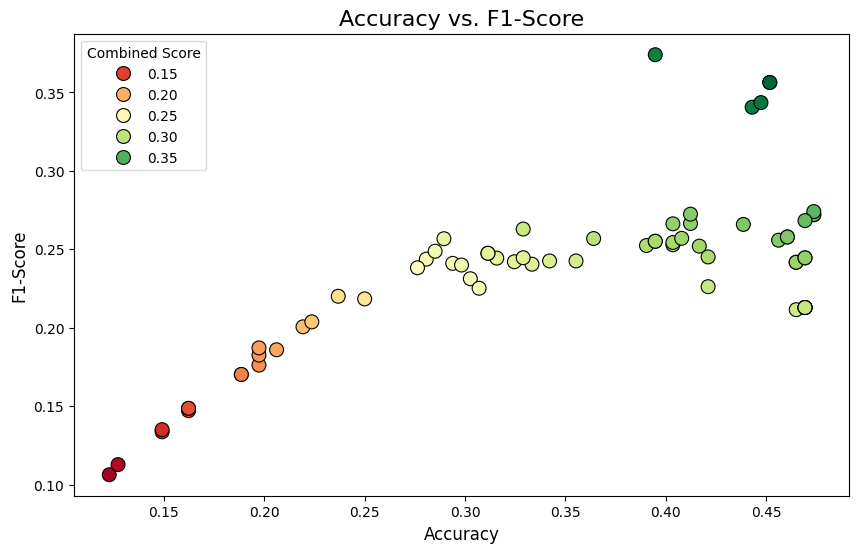

In [43]:
# Erstelle den Scatterplot mit Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='accuracy', y='f1', hue='combined_score', data=Model_prediction_scores, palette='RdYlGn', s=100, edgecolor='black')

# Hinzufügen von Titel und Labels
plt.title('Accuracy vs. F1-Score', fontsize=16)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)

# Zeige den Plot an
plt.legend(title='Combined Score')
plt.show()